In [12]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mohankrishnathalla/sleep-health-and-daily-performance-dataset/sleep_health_dataset.csv


In [13]:
import pandas as pd
path = '/kaggle/input/datasets/mohankrishnathalla/sleep-health-and-daily-performance-dataset/sleep_health_dataset.csv'
df = pd.read_csv(path)
df.head()

,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

In [15]:
df.isnull().sum()

person_id                      0
age                            0
gender                         0
occupation                     0
bmi                            0
country                        0
sleep_duration_hrs             0
sleep_quality_score            0
rem_percentage                 0
deep_sleep_percentage          0
sleep_latency_mins             0
wake_episodes_per_night        0
caffeine_mg_before_bed         0
alcohol_units_before_bed       0
screen_time_before_bed_mins    0
exercise_day                   0
steps_that_day                 0
nap_duration_mins              0
stress_score                   0
work_hours_that_day            0
chronotype                     0
mental_health_condition        0
heart_rate_resting_bpm         0
sleep_aid_used                 0
shift_work                     0
room_temperature_celsius       0
weekend_sleep_diff_hrs         0
season                         0
day_type                       0
cognitive_performance_score    0
sleep_diso

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
data = df.drop(['person_id'], axis=1)
le = LabelEncoder()
for col in data.columns:
    if data[col].dtype == 'object':
        data[col] = le.fit_transform(data[col].astype(str))
X = data.drop('sleep_disorder_risk', axis=1)
y = data['sleep_disorder_risk']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [17]:
import xgboost as xgb
from sklearn.metrics import accuracy_score, classification_report
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42,
    objective='multi:softprob'
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)
print(f"XGBoost Accuracy: {accuracy_score(y_test, y_pred_xgb) * 100:.2f}%")

XGBoost Accuracy: 94.70%


In [18]:
from sklearn.metrics import (
    precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report, roc_auc_score
)
precision = precision_score(y_test, y_pred_xgb, average='weighted')
print(f"Precision:{precision}")
y_probs = xgb_model.predict_proba(X_test)

Precision:0.9455183940083541


In [19]:
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_xgb))


Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     10892
           1       0.93      0.95      0.94      6673
           2       0.72      0.68      0.70      1626
           3       0.86      0.75      0.80       809

    accuracy                           0.95     20000
   macro avg       0.88      0.85      0.86     20000
weighted avg       0.95      0.95      0.95     20000



In [20]:
roc_auc = roc_auc_score(y_test, y_probs, multi_class='ovr', average='weighted')
print(f"ROC AUC Score:{roc_auc}")

ROC AUC Score:0.9960656172781983


In [21]:
f1 = f1_score(y_test, y_pred_xgb, average='weighted')
print(f"F1-Score:  {f1}")

F1-Score:  0.9460232461166243


In [22]:
recall = recall_score(y_test, y_pred_xgb, average='weighted')
print(f"Recall:{recall}")


Recall:0.947


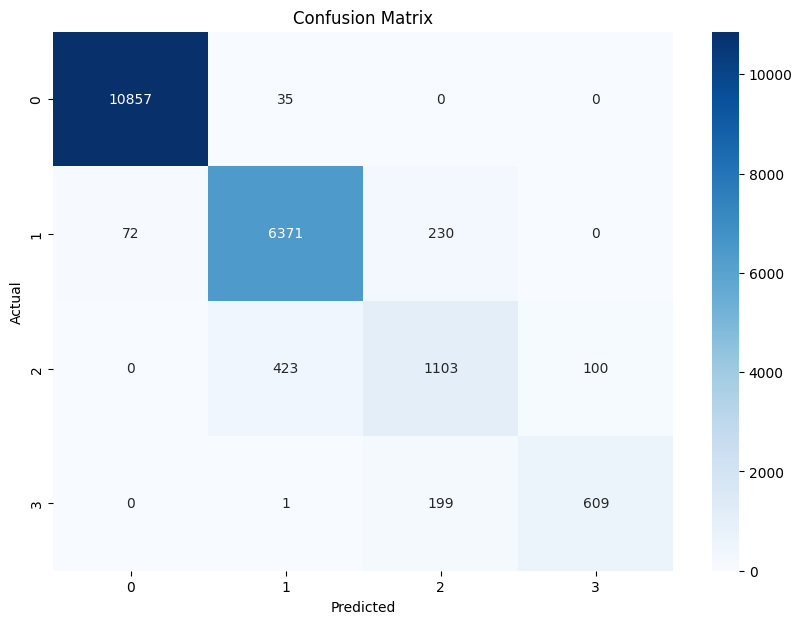

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))
cm = confusion_matrix(y_test, y_pred_xgb)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
